# data cleaning

In [1]:
# source additional data

# inflation
import pandas_datareader.data as web
import datetime

# consumer behavior - University of Michigan Consumer Sentiment
start = datetime.datetime(2021, 7, 1)
end = datetime.datetime(2026, 7, 9)

cpi = web.DataReader('CPIAUCSL', 'fred', start, end)
cpi = cpi.rename(columns={'CPIAUCSL': 'CPI'})
cpi = cpi.resample('D').ffill()  # CPI is monthly; forward-fill to daily

consumer_sentiment = web.DataReader('UMCSENT', 'fred', start, end)
consumer_sentiment = consumer_sentiment.resample('D').ffill()

# tariff events
import pandas as pd

tariff_events = pd.DataFrame({
    'Date': pd.to_datetime([
        '2026-07-20',  # real announcement dates
        '2026-04-02',
        '2026-02-12',
        '2025-02-01',
        '2025-01-20',
        '2025-04-02',
        '2024-12-11',
        '2024-09-18',
        '2024-06-14',
        '2024-05-14',
        '2024-05-22',
        '2023-02-24',
        '2023-12-26',
        '2022-03-23',
        '2022-03-28',
        '2022-05-09',
        '2022-11-29',
        '2022-12-21',
        '2021-01-01',
        '2021-03-08',
        '2021-06-15',
        '2021-06-17',
        '2021-10-04',
        '2021-10-31',
        '2021-11-10',
        '2020-01-15',
        '2020-02-14',
        '2020-02-17',
    ]),
    'tariff_event': 1
})



In [2]:
# clean missing values
import pandas as pd

sheet_id = "18GKpAX32KLyFbg5ggVFnME53ahjxVDqoYS2TT7IlS-Y"
sheet_name = "Sheet1"

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

df = pd.read_csv(url)


df.dropna(subset=['Date']).copy()
df['Date']=pd.to_datetime(df['Date'], format='%m/%d/%Y')
df = df.sort_values('Date').reset_index(drop=True)

close_cols = [c for c in df.columns if c.endswith('Close')]
for c in close_cols:
    df[c] = df[c].replace(r'[\$,]', '', regex=True).astype(float)

df['10 Yr'] = df['10 Yr'].ffill().bfill()
df['Crude Oil'] = df['Crude Oil'].ffill().bfill()

# type check pass
print(df.dtypes)
print(df.isna().sum()[df.isna().sum() > 0])

Date              datetime64[us]
AAPL Close               float64
AAPL Volume              float64
AMZN Close               float64
AMZN Volume              float64
GOOGL Close              float64
GOOGL Volume             float64
MSFT Close               float64
MSFT Volume              float64
META Close               float64
META Volume              float64
NVDA Close               float64
NVDA Volume              float64
Dell Close               float64
Dell Volume              float64
Exxon Close              float64
Exxon Volume             float64
CVX Close                float64
CVX Volume               float64
MPC Close                float64
MPC Volume               float64
PSX Close                float64
PSX Volume               float64
VLO Close                float64
VLO Volume               float64
ET Close                 float64
ET Volume                float64
COP Close                float64
COP Volume               float64
Treasury Dates               str
1 Mo      

In [8]:
print(df.columns.tolist())


# keep a copy of the base cleaned data BEFORE merging macro features
df_base = df.copy()
df_base.to_csv('data/cleaned_stock_data.csv', index=False)
print("Base cleaned data (no macro) saved.")

# merge in the macro data on a separate copy
df = df_base.copy()

if 'Date' in df.columns:
    df = df.set_index('Date')
elif df.index.name != 'Date':
    raise ValueError("Date not found as column or index — check df_base")

df = df.join(cpi, how='left')
df = df.join(consumer_sentiment, how='left')
df = df.merge(tariff_events.set_index('Date'), how='left', left_index=True, right_index=True)
df['tariff_event'] = df['tariff_event'].fillna(0)
df = df.ffill().bfill()  # bfill added so early rows aren't dropped entirely — see note below
df = df.reset_index()

df.to_csv('data/cleaned_stock_data_macro.csv', index=False)
print("Cleaned data with macro features saved.")

['Date', 'AAPL Close', 'AAPL Volume', 'AMZN Close', 'AMZN Volume', 'GOOGL Close', 'GOOGL Volume', 'MSFT Close', 'MSFT Volume', 'META Close', 'META Volume', 'NVDA Close', 'NVDA Volume', 'Dell Close', 'Dell Volume', 'Exxon Close', 'Exxon Volume', 'CVX Close', 'CVX Volume', 'MPC Close', 'MPC Volume', 'PSX Close', 'PSX Volume', 'VLO Close', 'VLO Volume', 'ET Close', 'ET Volume', 'COP Close', 'COP Volume', 'Treasury Dates', '1 Mo', '1.5 Month', '2 Mo', '3 Mo', '4 Mo', '6 Mo', '1 Yr', '2 Yr', '3 Yr', '5 Yr', '7 Yr', '10 Yr', '20 Yr', 'Oil Dates', 'Crude Oil', 'log_return', 'target', 'SMA_20', 'SMA_50', 'momentum_10', 'volatility_20', 'RSI_14', 'regime']
Base cleaned data (no macro) saved.
Cleaned data with macro features saved.


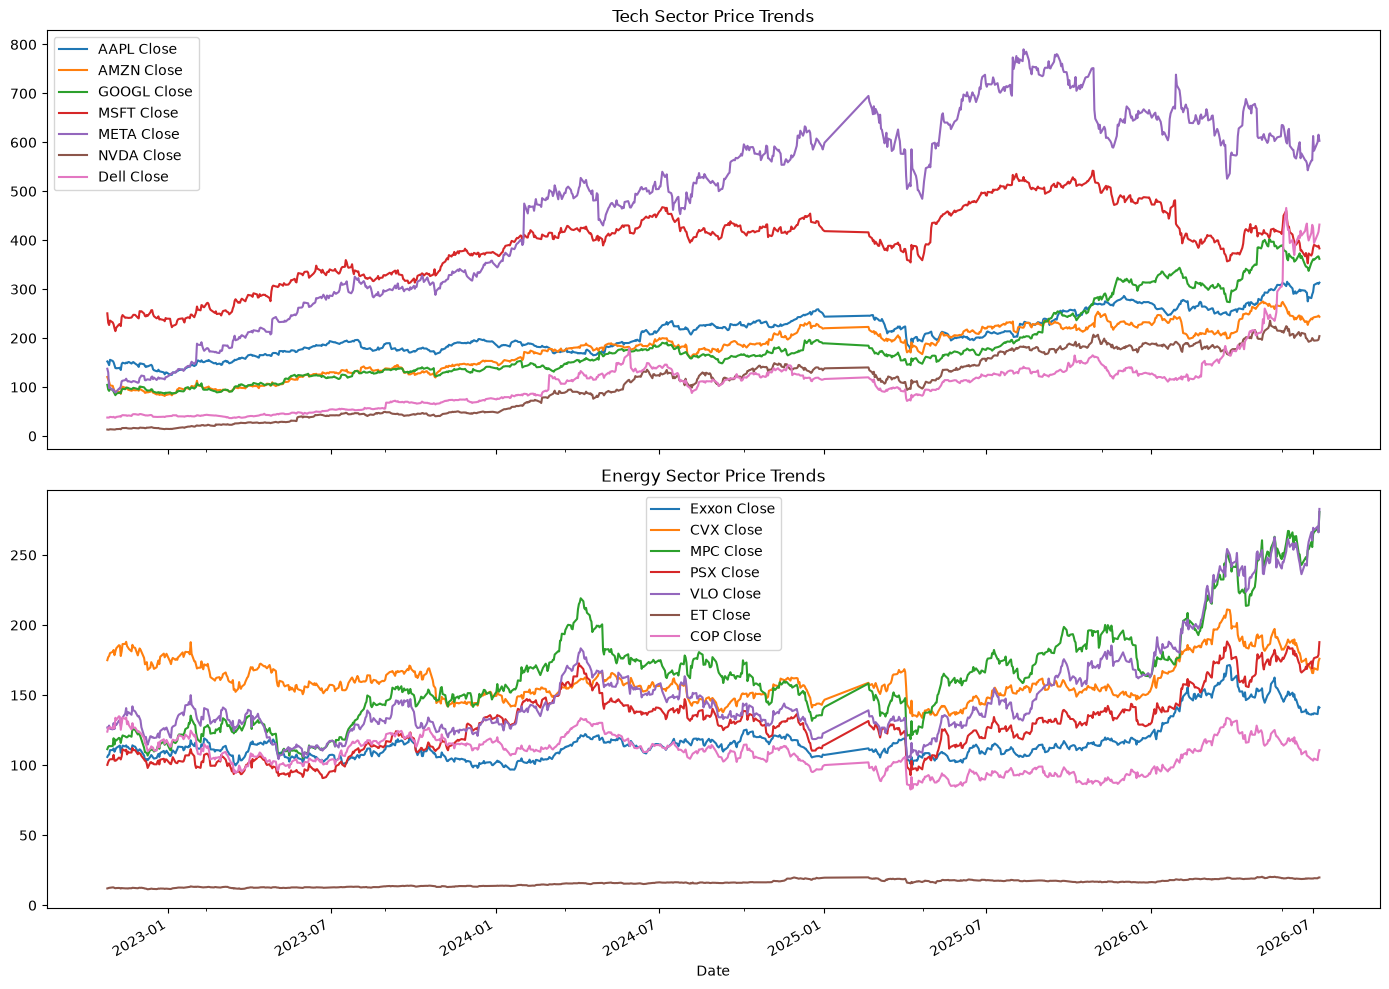

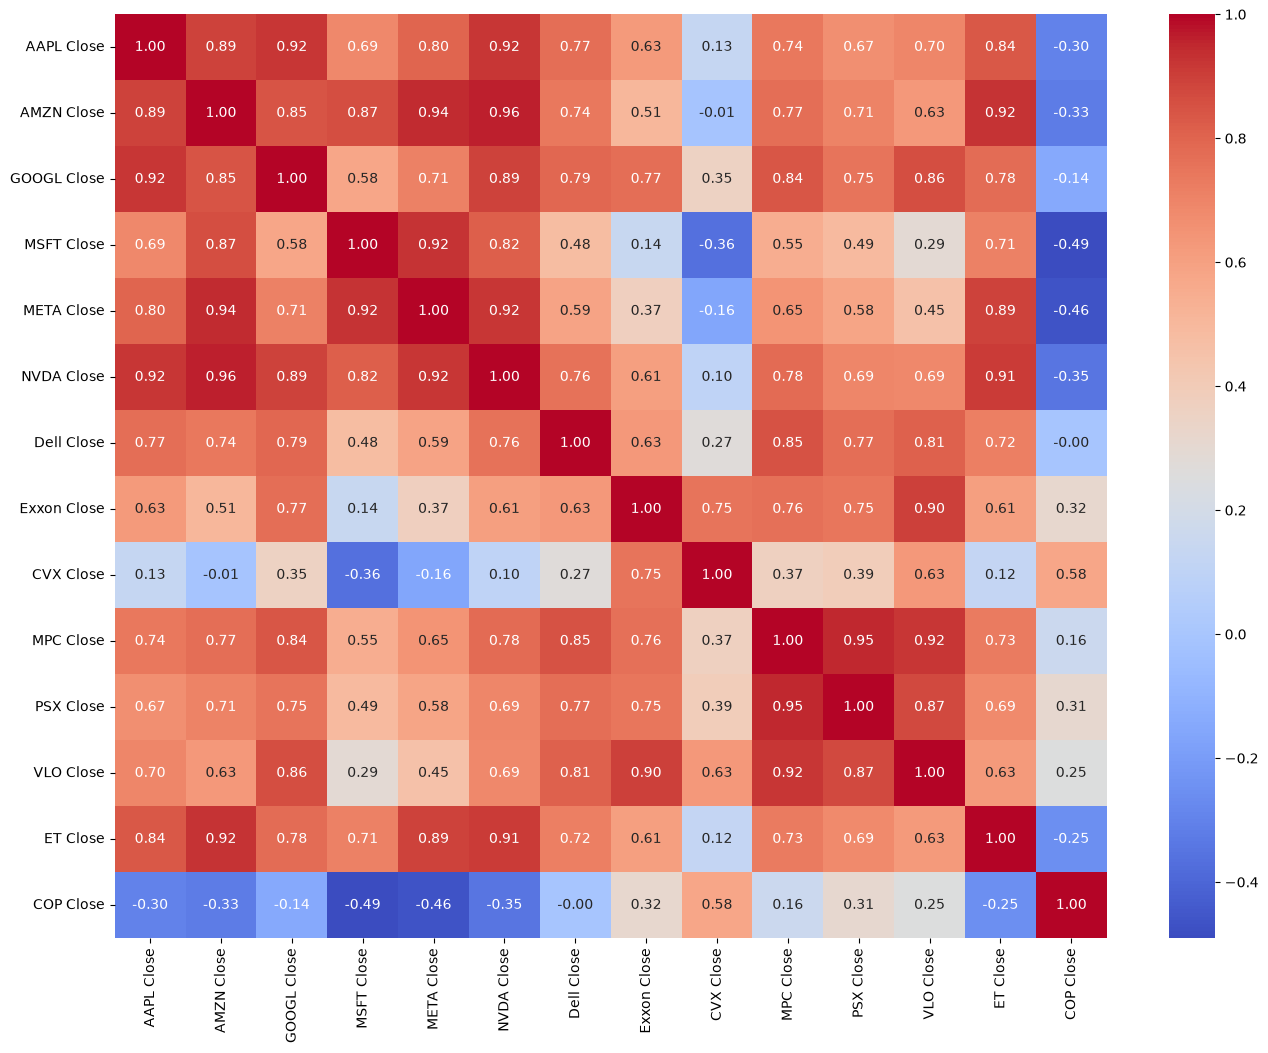

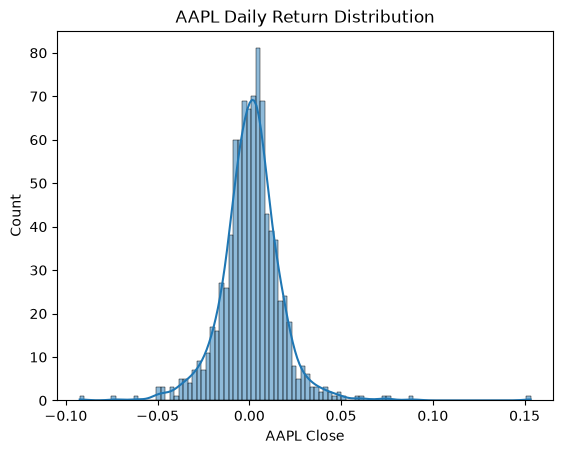

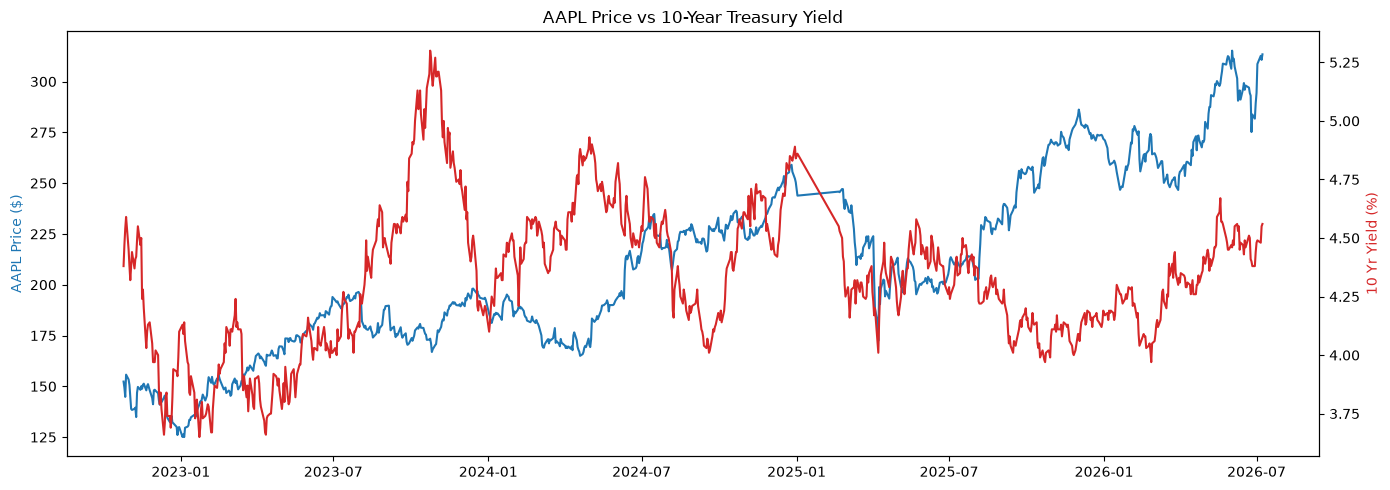

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# trend overview (tech vs energy)
tech_cols = ['AAPL Close', 'AMZN Close', 'GOOGL Close', 'MSFT Close', 'META Close', 'NVDA Close', 'Dell Close']
energy_cols = ['Exxon Close', 'CVX Close', 'MPC Close', 'PSX Close', 'VLO Close', 'ET Close', 'COP Close']

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
df.set_index('Date')[tech_cols].plot(ax=axes[0])
axes[0].set_title('Tech Sector Price Trends')

df.set_index('Date')[energy_cols].plot(ax=axes[1])
axes[1].set_title('Energy Sector Price Trends')
plt.tight_layout()
plt.show()

# Correlation heatmap
corr_cols = close_cols
plt.figure(figsize=(16, 12))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

# Return distribution
returns = df['AAPL Close'].pct_change().dropna()
sns.histplot(returns, bins=100, kde=True)
plt.title('AAPL Daily Return Distribution')
plt.show()

# macro line compared with stock line
fig, ax1 = plt.subplots(figsize=(14,5))
ax1.plot(df['Date'], df['AAPL Close'], color='tab:blue', label='AAPL Close')
ax1.set_ylabel('AAPL Price ($)', color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(df['Date'], df['10 Yr'], color='tab:red', label='10 Yr Yield')
ax2.set_ylabel('10 Yr Yield (%)', color='tab:red')

plt.title('AAPL Price vs 10-Year Treasury Yield')
fig.tight_layout()
plt.show()

# feature engineering

In [11]:
import numpy as np
# target variable
TARGET_TICKER = 'AAPL Close'
df['log_return'] = np.log(df[TARGET_TICKER] / df[TARGET_TICKER].shift(1))
df['target'] = df['log_return'].shift(-1)
df = df.dropna(subset=['target'])

# feature inputs: technical indicators

# Moving averages
df['SMA_20'] = df[TARGET_TICKER].rolling(20).mean()
df['SMA_50'] = df[TARGET_TICKER].rolling(50).mean()

# Momentum (rate of change over 10 days)
df['momentum_10'] = df[TARGET_TICKER].pct_change(10)

# Rolling volatility (20-day std of returns)
df['volatility_20'] = df['log_return'].rolling(20).std()

# RSI (14-day)
delta = df[TARGET_TICKER].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

df = df.dropna()

In [12]:
# label disruption vs stable periods
vol_threshold = df['volatility_20'].quantile(0.80)  # top 20% of volatility = disruption
df['regime'] = np.where(df['volatility_20'] > vol_threshold, 'disruption', 'stable')

print(df['regime'].value_counts())

regime
stable        677
disruption    169
Name: count, dtype: int64


In [13]:
# split into train/val/test sets
feature_cols = [
    'SMA_20', 'SMA_50', 'momentum_10', 'volatility_20', 'RSI_14',
    'CPI', 'UMCSENT', '10 Yr', 'Crude Oil', 'tariff_event'
]

X = df[feature_cols].values
y = df['target'].values

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val     = X[train_end:val_end], y[train_end:val_end]
X_test, y_test   = X[val_end:], y[val_end:]

print(X_train.shape, X_val.shape, X_test.shape)

(592, 10) (127, 10) (127, 10)
